# Tilted Scanner Validation: PACE OCI

This notebook validates TAT-C's representation of a cross-track scanner that tilts fore and aft against the [Ocean Color Instrument (OCI)](https://pace.gsfc.nasa.gov/) aboard NASA's Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) satellite. OCI is a hyperspectral radiometer with a rotating telescope that scans across track within about 56.5 deg of the scan center, covering a swath about 2,700 km wide from PACE's sun-synchronous orbit at 677 km altitude (ascending node at 13:00 local time). To avoid sun glint, which saturates ocean color observations near the subsolar point, the telescope tilts its scan plane 20 deg aft over the southern part of the orbit's day side and 20 deg forward over the northern part, flipping once per orbit near the subsolar latitude.

TAT-C represents such an instrument as a `PointedInstrument` in scan geometry (`view_geometry=ViewGeometry.SCAN`), whose fields of view are ranges of cross-track (scan) and along-track angles, and whose pitch angle tilts the scan plane. A pitch that varies around the orbit is given by a pitch angle profile (`pitch_angle_profile`), as a function of the satellite's argument of latitude (the angle from the ascending node). This notebook asks:

1. **Orbit.** Does TAT-C's propagation of the operational two-line element (TLE) set reproduce PACE's position?
2. **Scan geometry.** Does a tilted scan view reproduce OCI's geolocated pixels, and with which sign conventions and velocity frame?
3. **Tilt schedule.** Where does OCI's tilt flip, and can a pitch angle profile represent it?
4. **Observation times.** Does `collect_observations` predict when OCI observes points on the ground?

## Reference Data

The OCI Level-1B product (`PACE_OCI_L1B_SCI`, version 3) from the [NASA Ocean Biology Distributed Active Archive Center](https://oceancolor.gsfc.nasa.gov/) (OB.DAAC) provides one netCDF file per 5-minute granule of about 1,709 scans, each with its time, the telescope's tilt angle, the spacecraft's Earth-fixed position and velocity, and, for each of 1,272 pixels across the scan, the scan angle and the terrain-corrected geodetic latitude, longitude, and terrain height. The granules of two days (4 and 5 October 2026, about 280 granules of 1.3 to 1.9 GB each) are reduced with HTTP range requests (read with `h5py`, `pip install h5py`): the time and tilt of every scan, the navigation data of every tenth scan, and the pixel geolocation of every tenth scan and every eighth pixel. Downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package; the first run transfers about 5 GB and takes about 30 minutes, and the reduced data (about 60 MB) are cached in a local `data/pace` directory.

PACE's orbit is taken from its TLE from [CelesTrak](https://celestrak.org/) (epoch 5 October 2026, 19:09 UTC).

In [1]:
import concurrent.futures
import io
from datetime import datetime, timedelta, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "pace"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 10, 4, tzinfo=timezone.utc)
END = datetime(2026, 10, 6, tzinfo=timezone.utc)
SCAN_STEP, PIXEL_STEP = 10, 8
TLE = [
    "1 58928U 24025A   26278.79807078  .00000246  00000+0  53993-4 0  9990",
    "2 58928  98.0985 208.4896 0000629 276.8161  83.2970 14.65617987142132",
]

_sessions = []


def https_session():
    """An authenticated Earthdata HTTPS session, logging in on first use."""
    if not _sessions:
        import earthaccess

        earthaccess.login()
        _sessions.append(earthaccess.get_requests_https_session())
    return _sessions[0]


class RemoteFile(io.RawIOBase):
    """Read-only file object that downloads blocks of a remote file with HTTP range requests on demand."""

    def __init__(self, url, block_size=2**20, prefetch=1):
        self.block_size, self.blocks, self.position = block_size, {}, 0
        response = self._get(url, 0, prefetch * block_size)
        self.url, self.size = response.url, int(response.headers["Content-Range"].split("/")[1])
        self._store(0, response.content)

    def _get(self, url, start, end):
        for attempt in range(5):
            try:
                response = https_session().get(url, headers={"Range": f"bytes={start}-{end - 1}"}, timeout=300)
                response.raise_for_status()
                return response
            except requests.RequestException:
                if attempt == 4:
                    raise

    def _store(self, first, content):
        for i in range(0, len(content), self.block_size):
            self.blocks[first + i // self.block_size] = content[i : i + self.block_size]

    def readable(self):
        return True

    def seekable(self):
        return True

    def tell(self):
        return self.position

    def seek(self, offset, whence=io.SEEK_SET):
        self.position = {io.SEEK_SET: 0, io.SEEK_CUR: self.position, io.SEEK_END: self.size}[whence] + offset
        return self.position

    def readinto(self, buffer):
        n = min(len(buffer), self.size - self.position)
        if n <= 0:
            return 0
        first, last = self.position // self.block_size, (self.position + n - 1) // self.block_size
        missing = [block for block in range(first, last + 1) if block not in self.blocks]
        if missing:
            end = min((missing[-1] + 1) * self.block_size, self.size)
            self._store(missing[0], self._get(self.url, missing[0] * self.block_size, end).content)
        data = b"".join(self.blocks[block] for block in range(first, last + 1))
        offset = self.position - first * self.block_size
        buffer[:n] = data[offset : offset + n]
        self.position += n
        return n


def reduce_granule(url):
    """Reduce a granule to scan times and tilts, navigation, and subsampled pixel geolocation."""
    path = DATA_DIR / (url.rsplit("/", 1)[1].replace(".nc", ".npz"))
    columns = np.r_[np.arange(0, 1272, PIXEL_STEP), 1271]
    if path.exists():
        return path
    with h5py.File(RemoteFile(url), "r") as f:
        day = f["scan_line_attributes/time"].attrs["units"].decode().split()[-1]
        seconds = f["scan_line_attributes/time"][:]
        rows = slice(None, None, SCAN_STEP)

        def grid(name, scale=1.0):
            values = f[f"geolocation_data/{name}"][:][rows][:, columns].astype(np.float32)
            values[values <= -32767] = np.nan
            return values * scale

        np.savez_compressed(
            path,
            day=day,
            seconds=seconds,
            tilt=f["navigation_data/tilt_angle"][:],
            scan_quality=f["scan_line_attributes/scan_quality_flags"][:],
            nav_rows=np.arange(len(seconds))[rows],
            orb_pos=f["navigation_data/orb_pos"][:][rows],
            orb_vel=f["navigation_data/orb_vel"][:][rows],
            att_ang=f["navigation_data/att_ang"][:][rows],
            columns=columns,
            scan_angle=np.nanmedian(f["navigation_data/CCD_scan_angles"][::100][:, columns], axis=0),
            latitude=grid("latitude"),
            longitude=grid("longitude"),
            sensor_zenith=grid("sensor_zenith", 0.01),
            solar_zenith=grid("solar_zenith", 0.01),
            height=grid("height"),
        )
    return path


if not any(DATA_DIR.glob("PACE_OCI.*.npz")):
    import earthaccess

    results = earthaccess.search_data(short_name="PACE_OCI_L1B_SCI", temporal=(START.strftime("%Y-%m-%dT%H:%M:%SZ"), END.strftime("%Y-%m-%dT%H:%M:%SZ")))
    urls = sorted(next(link["URL"] for link in r["umm"]["RelatedUrls"] if link["URL"].startswith("https://obdaac-tea") and link["URL"].endswith(".nc")) for r in results)
    with concurrent.futures.ThreadPoolExecutor(6) as pool:
        list(pool.map(reduce_granule, urls))

granules = []
for path in sorted(DATA_DIR.glob("PACE_OCI.*.npz")):
    with np.load(path) as d:
        granule = {key: d[key] for key in d.files}
    times = pd.Timestamp(str(granule["day"]), tz="UTC") + pd.to_timedelta(granule["seconds"], unit="s")
    granule["name"], granule["times"], granule["nav_times"] = path.stem, times, times[granule["nav_rows"]]
    if granule["nav_times"][0] >= pd.Timestamp(START) and granule["nav_times"][0] < pd.Timestamp(END):
        granules.append(granule)
scans = pd.concat([pd.DataFrame({"time": g["times"], "tilt": g["tilt"]}) for g in granules]).sort_values("time").reset_index(drop=True)
nav = pd.concat(
    [
        pd.DataFrame(
            np.column_stack([g["orb_pos"], g["orb_vel"], g["att_ang"]]),
            columns=["x", "y", "z", "vx", "vy", "vz", "roll", "pitch", "yaw"],
        ).assign(time=g["nav_times"], granule=g["name"])
        for g in granules
    ]
).sort_values("time").reset_index(drop=True)
pd.Series(
    {
        "granules": len(granules),
        "scans": len(scans),
        "first scan": scans.time.min(),
        "last scan": scans.time.max(),
        "tilt angles (deg)": ", ".join(f"{v:.3f}" for v in sorted(scans.tilt.round(3).value_counts().index[:2])),
        "spacecraft roll, 95th percentile (deg)": nav.roll.abs().quantile(0.95),
        "spacecraft pitch, 95th percentile (deg)": nav.pitch.abs().quantile(0.95),
        "spacecraft yaw, range (deg)": f"{nav.yaw.min():.2f} to {nav.yaw.max():.2f}",
    }
)

granules                                                                   281
scans                                                                   471294
first scan                                 2026-10-04 00:07:58.641010765+00:00
last scan                                  2026-10-06 00:03:41.929418765+00:00
tilt angles (deg)                                              -19.827, 19.863
spacecraft roll, 95th percentile (deg)                                0.002192
spacecraft pitch, 95th percentile (deg)                               0.001661
spacecraft yaw, range (deg)                                      -4.02 to 0.17
dtype: object

Outside the tilt changes, the telescope tilt is -19.827 deg or +19.863 deg. The spacecraft's roll and pitch stay within a few thousandths of a degree of the orbital frame, while its yaw varies by about 4 deg: PACE is yaw-steered to align its scans with the ground track (Test 2).

## Setup

In [2]:
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.spatial import cKDTree
from skyfield.api import wgs84
from skyfield.framelib import itrs
from skyfield.positionlib import Geocentric
from skyfield.units import Distance, Velocity

from tatc.analysis import collect_observations
from tatc.constants import de421, timescale
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite
from tatc.utils import (
    VelocityFrame,
    ViewGeometry,
    compute_argument_of_latitude,
    compute_projected_ray_position,
    compute_view_angles,
    geodesic_distance,
)

orbit = GeneralPerturbationsOrbit.from_tle(TLE)
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})


def times_of(values):
    """Skyfield times of pandas timestamps."""
    return timescale.from_datetimes([t.to_pydatetime() for t in pd.DatetimeIndex(values)])


def ephemeris_track(frame):
    """The spacecraft's reported (Earth-fixed) position and velocity as an inertial orbit track."""
    return Geocentric.from_time_and_frame_vectors(
        times_of(frame.time),
        itrs,
        Distance(km=frame[["x", "y", "z"]].to_numpy(float).T),
        Velocity(km_per_s=frame[["vx", "vy", "vz"]].to_numpy(float).T),
    )


nav["argument_of_latitude"] = compute_argument_of_latitude(*(lambda track: (track.position.m, track.velocity.m_per_s))(ephemeris_track(nav)))

C:\Users\pgrogan\AppData\Local\Temp\ipykernel_27580\1808415648.py:29: UserWarning: Discarding nonzero nanoseconds in conversion.
  return timescale.from_datetimes([t.to_pydatetime() for t in pd.DatetimeIndex(values)])


## Test 1: Orbit

The TLE is propagated (SGP4) to the times of every tenth navigation record, and the propagated positions are compared with the reported ones in the along-track, cross-track, and radial directions.

In [3]:
sample = nav.iloc[::10]
tle_xyz = orbit.get_orbit_track(list(sample.time.dt.to_pydatetime())).frame_xyz(itrs).km
reported = sample[["x", "y", "z"]].to_numpy(float).T
velocity = sample[["vx", "vy", "vz"]].to_numpy(float).T
radial = reported / np.linalg.norm(reported, axis=0)
cross = np.cross(reported, velocity, axis=0)
cross /= np.linalg.norm(cross, axis=0)
along = np.cross(cross, radial, axis=0)
difference = tle_xyz - reported
errors = pd.DataFrame(
    {
        "time": sample.time.to_numpy(),
        "along-track (km)": np.sum(difference * along, axis=0),
        "cross-track (km)": np.sum(difference * cross, axis=0),
        "radial (km)": np.sum(difference * radial, axis=0),
        "total (km)": np.linalg.norm(difference, axis=0),
    }
)
errors.drop(columns="time").describe(percentiles=[0.5, 0.95]).loc[["mean", "50%", "95%", "max"]].round(3)

C:\Users\pgrogan\AppData\Local\Temp\ipykernel_27580\174024740.py:2: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  tle_xyz = orbit.get_orbit_track(list(sample.time.dt.to_pydatetime())).frame_xyz(itrs).km


,along-track (km),cross-track (km),radial (km),total (km)
mean,0.181,0.083,0.037,0.573
50%,0.170,0.091,0.018,0.545
95%,1.025,0.382,0.244,1.032
max,1.254,0.518,0.294,1.274


The propagated TLE is within 0.55 km (median) and 1.3 km (maximum) of PACE's reported positions over the two days before its epoch, mostly along track.

## Test 2: Scan Geometry

For a tilted scanner in scan geometry, TAT-C first tilts the nadir by the pitch angle about the cross-track axis, then rotates it by the scan angle (roll) about the tilted along-track axis, so that each scan sweeps a plane containing the cross-track axis. Each OCI pixel is compared with the ray that TAT-C casts for its scan angle and tilt from the spacecraft's reported position and velocity (isolating the instrument geometry from orbit errors), at the terrain height of the pixel, using `compute_projected_ray_position` with `tilt_angle` (as `PointedInstrument` does in scan geometry). OCI's positive tilt is forward and its positive scan angles are to the right of the direction of motion, so TAT-C's roll angle is the negative of the scan angle. Three variants are compared:

* **TAT-C (tilted scan plane)**: the Earth-fixed velocity frame (`VelocityFrame.EARTH_FIXED`, the default, as for a yaw-steered spacecraft);
* **inertial velocity frame**: the same with `VelocityFrame.INERTIAL`;
* **constant along-track angle**: the scan angle applied before the tilt, so that the rays keep a constant angle from the cross-track plane and sweep a cone rather than a plane (as TAT-C's scan geometry did before this validation).

Pixels are sampled from every scan row of every third granule (every 40th scan, every 32nd pixel), excluding scans during tilt changes.

In [4]:
def scan_geometry_errors(granule):
    """Distances (km) between OCI pixels and TAT-C rays for a granule's sampled scans."""
    rows = [k for k in range(2, len(granule["nav_rows"]), 4) if abs(abs(granule["tilt"][granule["nav_rows"][k]]) - 19.85) < 0.05]
    if not rows:
        return pd.DataFrame()
    frame = pd.DataFrame(np.column_stack([granule["orb_pos"][rows], granule["orb_vel"][rows]]), columns=["x", "y", "z", "vx", "vy", "vz"]).assign(time=granule["nav_times"][rows])
    output = []
    for k, row in enumerate(rows):
        track = ephemeris_track(frame.iloc[[k]])[0]
        tilt = float(granule["tilt"][granule["nav_rows"][row]])
        for j in range(0, len(granule["columns"]), 4):
            latitude, longitude, height = (float(granule[key][row, j]) for key in ("latitude", "longitude", "height"))
            if np.isnan(latitude):
                continue
            roll = -float(granule["scan_angle"][j])
            rays = {
                "TAT-C (tilted scan plane)": compute_projected_ray_position(track, 0, 0, roll, 0, elevation=height, tilt_angle=tilt),
                "inertial velocity frame": compute_projected_ray_position(track, 0, 0, roll, 0, elevation=height, velocity_frame=VelocityFrame.INERTIAL, tilt_angle=tilt),
                "constant along-track angle": compute_projected_ray_position(track, 0, 0, roll, tilt, elevation=height),
            }
            output.append(
                {
                    "scan angle (deg)": -roll,
                    "tilt (deg)": tilt,
                    "height (m)": height,
                    **{label: geodesic_distance(longitude, latitude, ray.longitude.degrees, ray.latitude.degrees) / 1e3 for label, ray in rays.items()},
                }
            )
    return pd.DataFrame(output)


geometry = pd.concat(Parallel(n_jobs=-1)(delayed(scan_geometry_errors)(g) for g in granules[::3])).reset_index(drop=True)
geometry["scan angle bin (deg)"] = pd.cut(geometry["scan angle (deg)"].abs(), [0, 10, 20, 30, 40, 50, 57], include_lowest=True)
labels2 = ["TAT-C (tilted scan plane)", "inertial velocity frame", "constant along-track angle"]
table2 = geometry.groupby("scan angle bin (deg)", observed=True)[labels2].agg(["median", lambda x: x.quantile(0.95)]).round(2)
table2.columns = [f"{label}, {'median' if stat == 'median' else '95th percentile'} (km)" for label, stat in table2.columns]
print(f"{len(geometry)} pixels from {len(granules[::3])} granules")
table2.T

155480 pixels from 94 granules


scan angle bin (deg),"(-0.001, 10.0]","(10.0, 20.0]","(20.0, 30.0]","(30.0, 40.0]","(40.0, 50.0]","(50.0, 57.0]"
"TAT-C (tilted scan plane), median (km)",0.79,0.70,1.56,1.91,4.58,8.92
"TAT-C (tilted scan plane), 95th percentile (km)",1.42,1.89,2.90,4.26,8.57,14.76
"inertial velocity frame, median (km)",14.04,17.04,22.65,31.23,43.57,62.89
"inertial velocity frame, 95th percentile (km)",17.77,22.70,30.82,42.41,60.71,86.64
"constant along-track angle, median (km)",3.96,14.87,34.22,63.86,121.94,210.50
"constant along-track angle, 95th percentile (km)",8.80,22.22,45.31,86.62,154.35,262.60


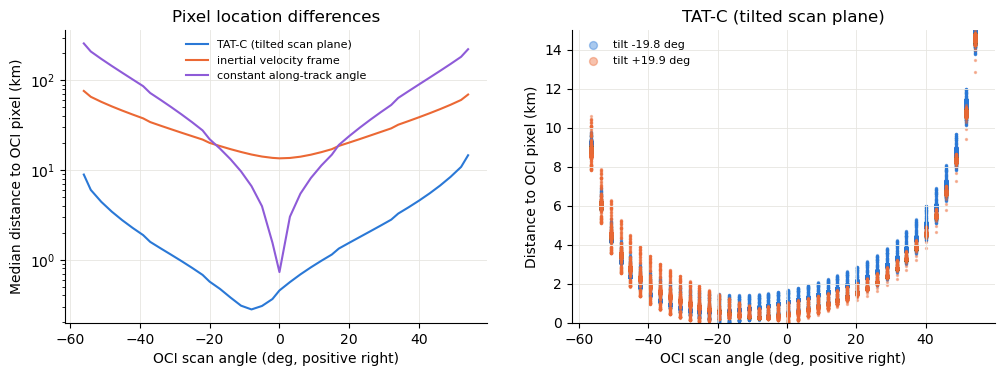

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for label, color in zip(labels2, [BLUE, ORANGE, PURPLE]):
    medians = geometry.groupby(geometry["scan angle (deg)"].round(0))[label].median()
    axes[0].plot(medians.index, medians.to_numpy(), color=color, label=label)
axes[0].set(xlabel="OCI scan angle (deg, positive right)", ylabel="Median distance to OCI pixel (km)", yscale="log", title="Pixel location differences")
axes[0].legend(frameon=False, fontsize=8)
for tilt, color in [(-19.827, BLUE), (19.863, ORANGE)]:
    subset = geometry[(geometry["tilt (deg)"] - tilt).abs() < 0.01]
    axes[1].scatter(subset["scan angle (deg)"], subset["TAT-C (tilted scan plane)"], s=2, color=color, alpha=0.4, label=f"tilt {tilt:+.1f} deg")
axes[1].set(xlabel="OCI scan angle (deg, positive right)", ylabel="Distance to OCI pixel (km)", ylim=(0, 15), title="TAT-C (tilted scan plane)")
axes[1].legend(frameon=False, fontsize=8, markerscale=4)
plt.show()

In the Earth-fixed velocity frame, TAT-C's tilted scan reproduces OCI's pixels within 0.8 km (median) near nadir, 1.6 to 1.9 km at scan angles of 20 to 40 deg, and 9 km at the swath edges (95th percentile 15 km). This confirms the conventions: OCI's positive tilt is TAT-C's positive (forward) pitch, its scan angles are the negative of TAT-C's roll angles, and its scans are aligned with the ground track (PACE is yaw-steered). In the inertial velocity frame, the scans would be rotated by up to 4 deg, misplacing the pixels by 14 km at nadir (where the 20 deg tilt carries the rotation into a cross-track shift) and 63 km at the edges.

Tilting the scan plane, rather than offsetting each ray by a constant along-track angle, is essential: with a constant along-track angle of 20 deg, the rays sweep a cone ahead of (or behind) the satellite that curves away from the scan line toward the edges, misplacing the pixels by 15 km at 15 deg, 64 km at 35 deg, and 210 km at the swath edges. OCI's telescope tilts its whole scan plane, which TAT-C's scan geometry now represents (the pitch angle tilts the scan plane before the scan angle is applied).

The remaining differences at the edges (up to about 0.2 deg) are a combination of a roll offset of 0.03 to 0.09 deg (which differs between the two tilts), a scan angle scale 0.3% larger than the reported scan angles, and a rotation of the scan line of about 0.08 deg about the boresight. These details of OCI's scan mechanism and alignment are not modeled.

## Test 3: Tilt Schedule

The tilt changes are the runs of scans with tilts between -19.5 and +19.5 deg. Their start and end are located in argument of latitude (interpolated from the navigation records), and in latitude from the spacecraft's position.

In [6]:
scans["changing"] = scans.tilt.abs() < 19.5
scans["run"] = (scans.changing != scans.changing.shift()).cumsum()
flips = scans[scans.changing].groupby("run").agg(start=("time", "min"), end=("time", "max"), tilt_before=("tilt", "first"), tilt_after=("tilt", "last")).reset_index(drop=True)
unwrapped = np.unwrap(np.radians(nav.argument_of_latitude.to_numpy()))
nav_ns = nav.time.astype("int64").to_numpy()


def argument_at(times):
    return np.degrees(np.interp(pd.DatetimeIndex(times).astype("int64"), nav_ns, unwrapped)) % 360


latitude_ns = np.degrees(np.arcsin(nav.z / np.sqrt(nav.x**2 + nav.y**2 + nav.z**2)))
flips["day"] = flips.start.dt.strftime("%Y-%m-%d")
flips["direction"] = np.where(flips.tilt_after > flips.tilt_before, "aft to forward", "forward to aft")
flips["argument of latitude, start (deg)"] = argument_at(flips.start)
flips["argument of latitude, end (deg)"] = argument_at(flips.end)
flips["latitude, start (deg)"] = np.interp(flips.start.astype("int64"), nav_ns, latitude_ns)
flips["duration (s)"] = (flips.end - flips.start).dt.total_seconds()
summary3 = flips.groupby(["day", "direction"]).agg(
    changes=("start", "size"),
    first=("start", "min"),
    last=("start", "max"),
    **{
        "argument of latitude, start (deg)": ("argument of latitude, start (deg)", "median"),
        "argument of latitude, end (deg)": ("argument of latitude, end (deg)", "median"),
        "start, spread (deg)": ("argument of latitude, start (deg)", lambda x: np.ptp(np.degrees(np.unwrap(np.radians(x))))),
        "latitude, start (deg)": ("latitude, start (deg)", "median"),
        "duration (s)": ("duration (s)", "median"),
    },
)
summary3.round(3).T

day,2026-10-04,2026-10-05
direction,aft to forward,aft to forward
changes,15,14
first,2026-10-04 00:33:06.651242765+00:00,2026-10-05 01:06:00.543151765+00:00
last,2026-10-04 23:29:27.671156765+00:00,2026-10-05 22:24:02.530220765+00:00
"argument of latitude, start (deg)",0.038,353.54
"argument of latitude, end (deg)",1.721,355.216
"start, spread (deg)",0.06,0.06
"latitude, start (deg)",-0.097,-6.529
duration (s),27.549,27.549


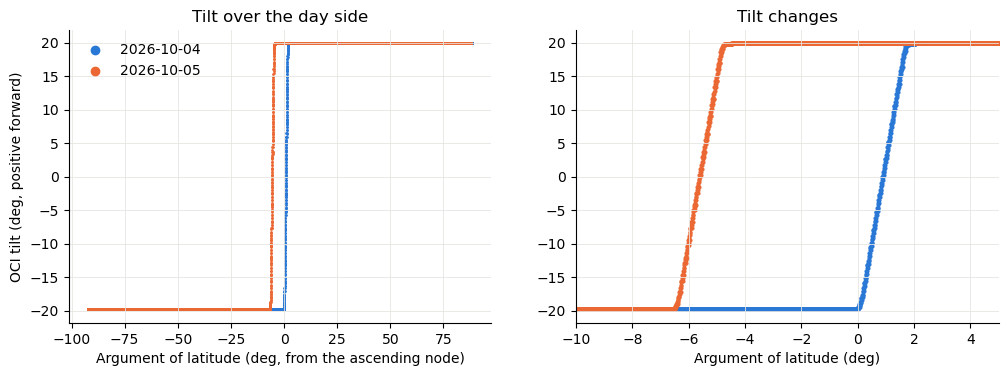

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (day, frame), color in zip(nav.groupby(nav.time.dt.strftime("%Y-%m-%d")), [BLUE, ORANGE]):
    tilt = np.interp(frame.time.astype("int64"), scans.time.astype("int64"), scans.tilt)
    u = (frame.argument_of_latitude + 180) % 360 - 180
    axes[0].scatter(u, tilt, s=1, color=color, label=day)
    axes[1].scatter(u, tilt, s=4, color=color, label=day)
axes[0].set(xlabel="Argument of latitude (deg, from the ascending node)", ylabel="OCI tilt (deg, positive forward)", title="Tilt over the day side")
axes[1].set(xlabel="Argument of latitude (deg)", xlim=(-10, 5), title="Tilt changes")
axes[0].legend(frameon=False, markerscale=6)
plt.show()

OCI changes its tilt once per orbit on the day side, from aft (-19.83 deg) to forward (+19.86 deg), over 27.5 s (1.7 deg of argument of latitude); the reverse change happens on the night side, where OCI does not collect data. On each day, every change starts at the same argument of latitude (within 0.06 deg): at the ascending node (0.04 deg, latitude -0.1 deg) on 4 October, and 6.5 deg earlier (353.5 deg, latitude -6.5 deg) on 5 October. The schedule follows the subsolar latitude through the year (in steps between days): for example, the change was at 6.5 deg north on 20 September and at 24.6 deg south and 22.4 deg north on 21 December 2025 and 21 June 2026. Within a day, a pitch angle profile in argument of latitude represents it: -19.827 deg until the start of the change, +19.863 deg from its end, and back on the night side.

## Test 4: Observation Times

The points of interest are those of a Fibonacci lattice with a typical spacing of 500 km. For each point and each OCI pass over it, the observation time is the time of the scan through the point, interpolated between the sampled scans of the nearest sampled pixel. Passes are those whose nearest sampled pixel is within 30 km (sampled pixels are up to about 45 km apart near the swath edges), excluding the outermost sampled pixels of the scan and passes during a tilt change (whose scans are too sparse to locate a point's observation).

`collect_observations` predicts the observations of an OCI `PointedInstrument` in scan geometry (112.9 deg across track, the range of OCI's scan angles; 0.1 deg along track; a field of regard of 120 deg, enough for the tilted scan edges; and a minimum solar elevation of -8 deg at the target, for observations on the day side only, as OCI collects data near the terminator up to solar elevations of about -7 deg), with three pitch models:

* **pitch profile, per day**: each day's tilt schedule from Test 3 as a pitch angle profile (-19.827 deg before the change and +19.863 deg after it, changing linearly over its duration, and back at an argument of latitude of 180 deg, on the night side), for the analysis of that day;
* **pitch profile, first day**: the first day's profile for both days;
* **no tilt**: a pitch angle of 0.

In [8]:
lattice = generate_points_fibonacci_lattice(500e3)
points = [Point(id=i, latitude=r.geometry.y, longitude=r.geometry.x) for i, r in enumerate(lattice.itertuples())]
point_xyz = np.array([wgs84.latlon(p.latitude, p.longitude).itrs_xyz.m for p in points])

# OCI observation times from the sampled pixels
pixel_xyz, pixel_index = [], []
for gi, g in enumerate(granules):
    valid = ~np.isnan(g["latitude"])
    rows, cols = np.nonzero(valid)
    position = wgs84.latlon(g["latitude"][valid], g["longitude"][valid], g["height"][valid]).itrs_xyz.m.T
    pixel_xyz.append(position)
    pixel_index.append(np.column_stack([np.full(len(rows), gi), rows, cols]))
pixel_xyz, pixel_index = np.concatenate(pixel_xyz), np.concatenate(pixel_index)
tree = cKDTree(pixel_xyz)
flip_times = pd.DatetimeIndex(np.concatenate([flips.start.to_numpy(), flips.end.to_numpy()]))
reference = []
for pid, xyz in enumerate(point_xyz):
    nearby = tree.query_ball_point(xyz, 30e3)
    if not nearby:
        continue
    candidates = pd.DataFrame(pixel_index[nearby], columns=["granule", "row", "column"]).assign(distance=np.linalg.norm(pixel_xyz[nearby] - xyz, axis=1))
    candidates["time"] = [granules[g]["nav_times"][r] for g, r in zip(candidates.granule, candidates.row)]
    candidates["pass"] = (candidates.sort_values("time").time.diff().dt.total_seconds() > 600).cumsum().reindex(candidates.index)
    for _, group in candidates.sort_values("time").groupby((candidates.sort_values("time").time.diff().dt.total_seconds() > 600).cumsum()):
        best = group.loc[group.distance.idxmin()]
        g, r, c = granules[int(best.granule)], int(best.row), int(best.column)
        if c in (0, len(g["columns"]) - 1):
            continue
        # interpolate the time of the scan through the point between adjacent sampled scans
        r0, r1 = (r, r + 1) if r + 1 < len(g["nav_rows"]) else (r - 1, r)
        x0, x1 = (wgs84.latlon(g["latitude"][k, c], g["longitude"][k, c], g["height"][k, c]).itrs_xyz.m for k in (r0, r1))
        fraction = np.dot(xyz - x0, x1 - x0) / np.dot(x1 - x0, x1 - x0)
        time = g["nav_times"][r0] + (g["nav_times"][r1] - g["nav_times"][r0]) * float(fraction)
        if ((flips.start - pd.Timedelta(seconds=2) <= time) & (time <= flips.end + pd.Timedelta(seconds=2))).any():
            continue
        reference.append({"point_id": points[pid].id, "latitude": points[pid].latitude, "time": time, "scan angle (deg)": float(g["scan_angle"][c])})
reference = pd.DataFrame(reference)
reference = reference[(reference.time >= pd.Timestamp(START)) & (reference.time < pd.Timestamp(END))].reset_index(drop=True)
# time from the nearest tilt change
reference["from tilt change (s)"] = [np.min(np.abs((flip_times - t).total_seconds())) for t in reference.time]
# periods of OCI data collection (scans less than 5 s apart)
collecting = scans.time.diff().dt.total_seconds().gt(5).cumsum()
collection = scans.groupby(collecting).time.agg(["min", "max"])


def profile(day):
    """Pitch angle profile of a day's tilt schedule."""
    rows = flips[(flips.day == day) & (flips.direction == "aft to forward")]
    start, end = np.median(rows["argument of latitude, start (deg)"]), np.median(rows["argument of latitude, end (deg)"])
    return [(float(start), -19.827), (float(end), 19.863), (178.0, 19.863), (182.0, -19.827)]


days = sorted(flips.day.unique())


def oci(**kwargs):
    return PointedInstrument(
        name="OCI", field_of_regard=120, cross_track_field_of_view=112.9, along_track_field_of_view=0.1,
        is_rectangular=True, view_geometry=ViewGeometry.SCAN, min_target_solar_elevation=-8, **kwargs,
    )


models = {
    "pitch profile, per day": [(oci(pitch_angle_profile=profile(day)), day) for day in days],
    "pitch profile, first day": [(oci(pitch_angle_profile=profile(days[0])), day) for day in days],
    "no tilt": [(oci(), day) for day in days],
}


def observe(point, instrument, day):
    satellite = Satellite(name="PACE", orbit=orbit, instruments=[instrument])
    start = datetime.fromisoformat(day).replace(tzinfo=timezone.utc)
    return collect_observations(point, satellite, start, start + timedelta(days=1)).assign(point_id=point.id)


predicted = {}
for label, runs in models.items():
    frames = Parallel(n_jobs=-1)(delayed(observe)(point, instrument, day) for instrument, day in runs for point in points)
    predicted[label] = pd.concat([f for f in frames if not f.empty])[["point_id", "epoch", "geometry"]]


def scan_angle(frame, instrument_by_day):
    """OCI scan angles (deg, positive right) of predicted observations."""
    angles = []
    for row in frame.itertuples():
        track = orbit.get_orbit_track(row.epoch.to_pydatetime())
        instrument = instrument_by_day[row.epoch.strftime("%Y-%m-%d")]
        roll, _ = compute_view_angles(track, wgs84.latlon(row.geometry.y, row.geometry.x), tilt_angle=instrument.get_pitch_angle(track))
        angles.append(-float(roll))
    return angles

rows4, matched4, found4 = {}, {}, {}
for label, frame in predicted.items():
    merged = pd.merge_asof(
        reference.sort_values("time"),
        frame.rename(columns={"epoch": "predicted"}).sort_values("predicted"),
        left_on="time", right_on="predicted", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=3),
    )
    merged["difference (s)"] = (merged.predicted - merged.time).dt.total_seconds()
    matched4[label] = merged
    near = merged["from tilt change (s)"] < 120
    # predicted observations while OCI collected data, inside its sampled swath, away from tilt changes
    inside = np.zeros(len(frame), bool)
    for start, end in collection.itertuples(index=False):
        inside |= (frame.epoch >= start).to_numpy() & (frame.epoch <= end).to_numpy()
    candidates = frame[inside & np.array([np.min(np.abs((flip_times - t).total_seconds())) > 30 for t in frame.epoch])].copy()
    candidates["scan angle (deg)"] = scan_angle(candidates, dict(zip(days, [instrument for instrument, _ in models[label]])))
    candidates = candidates[candidates["scan angle (deg)"].abs() < 55.5]
    found = pd.merge_asof(
        candidates.sort_values("epoch"), reference[["point_id", "time"]].sort_values("time"),
        left_on="epoch", right_on="time", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=3),
    )
    found4[label] = found
    rows4[label] = {
        "OCI observations": len(merged),
        "matched (%)": 100 * merged.predicted.notna().mean(),
        "time difference, median (s)": merged["difference (s)"].abs().median(),
        "time difference, 95th percentile (s)": merged["difference (s)"].abs().quantile(0.95),
        "time difference, max (s)": merged["difference (s)"].abs().max(),
        "within 2 min of a tilt change: observations": int(near.sum()),
        "within 2 min of a tilt change: time difference, max (s)": merged.loc[near, "difference (s)"].abs().max(),
        "TAT-C observations in OCI's collection and swath": len(found),
        "found in OCI data (%)": 100 * found.time.notna().mean(),
    }
pd.DataFrame(rows4).T.round(2)

C:\Users\pgrogan\AppData\Local\Temp\ipykernel_27580\510968519.py:86: UserWarning: Discarding nonzero nanoseconds in conversion.
  track = orbit.get_orbit_track(row.epoch.to_pydatetime())


C:\Users\pgrogan\AppData\Local\Temp\ipykernel_27580\510968519.py:86: UserWarning: Discarding nonzero nanoseconds in conversion.
  track = orbit.get_orbit_track(row.epoch.to_pydatetime())


C:\Users\pgrogan\AppData\Local\Temp\ipykernel_27580\510968519.py:86: UserWarning: Discarding nonzero nanoseconds in conversion.
  track = orbit.get_orbit_track(row.epoch.to_pydatetime())


,OCI observations,matched (%),"time difference, median (s)","time difference, 95th percentile (s)","time difference, max (s)",within 2 min of a tilt change: observations,"within 2 min of a tilt change: time difference, max (s)",TAT-C observations in OCI's collection and swath,found in OCI data (%)
"pitch profile, per day",7533.0,100.00,0.15,0.45,0.95,618.0,0.63,7062.0,100.00
"pitch profile, first day",7533.0,99.91,0.15,0.49,77.86,618.0,77.86,7152.0,99.16
no tilt,7533.0,91.16,38.11,42.94,46.22,618.0,43.10,6404.0,99.20


In [9]:
found = found4["pitch profile, per day"]
found["day"] = found.epoch.dt.strftime("%Y-%m-%d")
found["scan angle bin (deg)"] = pd.cut(found["scan angle (deg)"].abs(), [0, 20, 40, 50, 55.5])
found.groupby(["day", "scan angle bin (deg)"], observed=True).time.agg(predicted="size", found=lambda x: 100 * x.notna().mean()).rename(columns={"found": "found in OCI data (%)"}).round(2).unstack(0)

predicted            found in OCI data (%)           
day                  2026-10-04 2026-10-05            2026-10-04 2026-10-05
scan angle bin (deg)                                                       
(0.0, 20.0]                 803        695                 100.0      100.0
(20.0, 40.0]               1118        992                 100.0      100.0
(40.0, 50.0]                948        860                 100.0      100.0
(50.0, 55.5]                874        772                 100.0      100.0

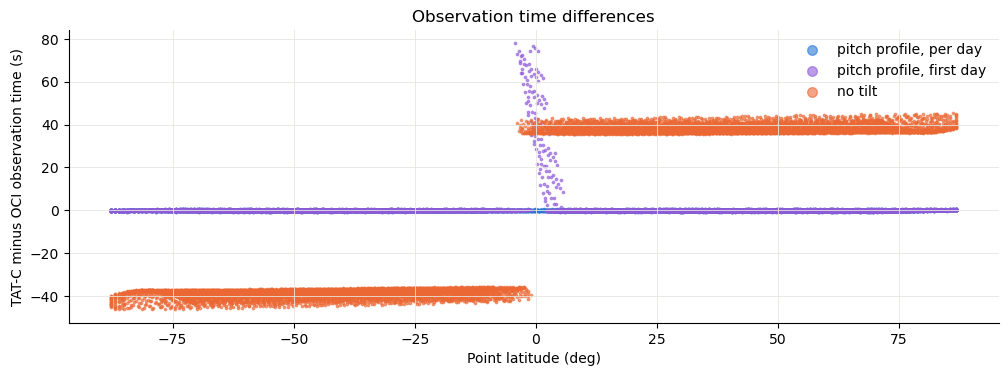

In [10]:
fig, ax = plt.subplots(figsize=(12, 3.8))
for (label, merged), color in zip(matched4.items(), [BLUE, PURPLE, ORANGE]):
    ax.scatter(merged.latitude, merged["difference (s)"], s=3, color=color, label=label, alpha=0.6)
ax.set(xlabel="Point latitude (deg)", ylabel="TAT-C minus OCI observation time (s)", title="Observation time differences")
ax.legend(frameon=False, markerscale=4)
plt.show()

With each day's pitch angle profile, `collect_observations` reproduces OCI's observations: all 7,533 OCI observations of the points are matched, within 0.15 s (median) and 0.95 s (maximum), including the 618 within 2 minutes of a tilt change (within 0.63 s), and all 7,062 predicted observations within OCI's data collection and swath are found in its data. Without the tilt, the predicted observations are 38 s late (in the northern part of the orbit) or early (in the southern part), the time the satellite takes to travel the 260 km between the nadir and the tilted scan line, and 9% of OCI's observations are missed, as the untilted scan reaches less far across track (56.5 deg from nadir at its edges, instead of 58.8 deg for the tilted scan). With the first day's profile on both days, the observations between the two days' tilt changes, about 700 km of ground track per orbit on the second day, are predicted with the wrong tilt, up to 78 s from OCI's.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (TLE) | within 0.55 km (median) and 1.3 km (maximum) |
| 2. Scan geometry (`ViewGeometry.SCAN`, pitch tilting the scan plane) | pixels within 0.8 km near nadir and 9 km at the swath edges (median), with the Earth-fixed velocity frame; a constant along-track angle would misplace the edges by 210 km, and the inertial frame by 63 km |
| 3. Tilt schedule (`pitch_angle_profile`) | one change per orbit on the day side, over 27.5 s, at the same argument of latitude within 0.06 deg each day; the schedule moves between days with the subsolar latitude |
| 4. Observation times (`collect_observations`) | with a per-day pitch profile, all OCI observations matched, within 0.15 s (median) and 0.95 s (maximum); 38 s off without the tilt; up to 78 s off with the previous day's profile |

**Tilted scanners.** A `PointedInstrument` in scan geometry with a pitch angle represents a cross-track scanner whose scan plane tilts fore or aft, such as OCI (and SeaWiFS before it), and a pitch angle profile represents its tilt changes around the orbit.

**Changes to TAT-C.** This validation added a pitch angle profile (`PointedInstrument.pitch_angle_profile`, as a function of argument of latitude, like `roll_angle_profile`) and changed scan geometry so that the pitch angle tilts the scan plane (as `tilt_angle` in `compute_projected_ray_position` and `compute_view_angles`); previously, scan geometry applied the pitch angle after the scan angle, sweeping a cone that misplaced the edges of a tilted scan by 210 km.

**Limitations.** The tilt schedule changes between days, so analyses longer than a day need a profile per day (or a profile fitted to the period, with errors where the schedule moved). OCI's collection window (from pole to pole on the ascending day side, as observed) is approximated here by a minimum solar elevation of the target.